# Random Forest Model Performance

This notebook reviews the latest random forest outputs produced by `model_training.ipynb` under the spatial workflow. Final performance is the fixed NUTS3 test-set performance; training-region spatial CV remains a tuning diagnostic.


In [1]:
from __future__ import annotations

import json
import sys
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
try:
    from IPython.display import display
except Exception:
    display = print


In [2]:
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pipeline" / "config").exists()
)
sys.path.append(str(REPO_ROOT))
from pipeline.utils.paths import load_paths, path_value

rf_utils = import_module("pipeline.3_epvi_prediction.utils")
latest_file = rf_utils.latest_file
PATHS = load_paths()
MODEL_OUT_DIR = path_value(PATHS, "external_data_root") / "outputs" / "epvi_prediction" / "random_forest"

# Must match the scope used in model_training.ipynb for the outputs being inspected.
EXCLUDE_OVERSEAS_TERRITORIES = False
OVERSEAS_NUTS3 = tuple(rf_utils.OVERSEAS_NUTS3)
MODEL_SCOPE_LABEL = "mainland_only" if EXCLUDE_OVERSEAS_TERRITORIES else "all_territories"

metrics_path = latest_file(MODEL_OUT_DIR, "rf_epvi_metrics_*.csv")
predictions_path = latest_file(MODEL_OUT_DIR, "rf_epvi_predictions_residuals_*.csv")
importances_path = latest_file(MODEL_OUT_DIR, "rf_epvi_feature_importances_*.csv")
params_path = latest_file(MODEL_OUT_DIR, "rf_epvi_best_params_*.json")
folds_path = latest_file(MODEL_OUT_DIR, "rf_epvi_spatial_cv_folds_*.csv")
permutation_path = latest_file(MODEL_OUT_DIR, "rf_epvi_permutation_importances_*.csv")
required = {"metrics": metrics_path, "predictions": predictions_path, "importances": importances_path, "params": params_path, "spatial folds": folds_path}
missing = [name for name, path in required.items() if path is None]
if missing:
    raise FileNotFoundError(f"Missing model outputs in {MODEL_OUT_DIR}: {missing}. Run the spatial training notebook first.")

print("model output folder:", MODEL_OUT_DIR)
print("expected model scope:", MODEL_SCOPE_LABEL)
for name, path in required.items():
    print(f"{name}:", path)
if permutation_path is not None:
    print("permutation importances:", permutation_path)


model output folder: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest
metrics: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_metrics_20260526_000504.csv
predictions: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_predictions_residuals_20260526_000504.csv
importances: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_feature_importances_20260526_000504.csv
params: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_best_params_20260526_000504.json
spatial folds: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\epvi_prediction\random_forest\rf_epvi_spatial_cv_folds_2

In [3]:
metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path)
importances = pd.read_csv(importances_path)
folds = pd.read_csv(folds_path)
with open(params_path, "r", encoding="utf-8") as f:
    best_params = json.load(f)
permutation_importances = pd.read_csv(permutation_path) if permutation_path is not None else pd.DataFrame()

has_overseas_predictions = predictions["NUTS3"].isin(OVERSEAS_NUTS3).any()
if EXCLUDE_OVERSEAS_TERRITORIES and has_overseas_predictions:
    raise ValueError(
        "The latest model outputs include PT200/PT300, but EXCLUDE_OVERSEAS_TERRITORIES=True. "
        "Rerun model_training.ipynb with the same scope switch before using this notebook."
    )
if not EXCLUDE_OVERSEAS_TERRITORIES and not has_overseas_predictions:
    print("WARNING: latest outputs do not contain overseas territories; they look like a mainland-only run.")

target_order = metrics.sort_values("fixed_test_r2", ascending=False)["target"].tolist()
for df in [metrics, predictions, importances]:
    df["target"] = pd.Categorical(df["target"], categories=target_order, ordered=True)
print("targets:", target_order)
display(folds.sort_values(["target", "fold"]))


targets: ['AIAM', 'EPVI cooling', 'EPG cooling', 'EPVI heating', 'EPG heating']


,target,fold,n_rows,n_nuts3,validation_nuts3
10,AIAM,0,478,4,"PT11A, PT11B, PT181, PT200"
11,AIAM,1,490,5,"PT11C, PT150, PT16D, PT170, PT300"
12,AIAM,2,504,4,"PT11D, PT16G, PT184, PT187"
13,AIAM,3,503,4,"PT111, PT119, PT16H, PT185"
14,AIAM,4,499,4,"PT11E, PT16E, PT16F, PT186"
5,EPG cooling,0,478,4,"PT11A, PT11B, PT181, PT200"
6,EPG cooling,1,490,5,"PT11C, PT150, PT16D, PT170, PT300"
7,EPG cooling,2,504,4,"PT11D, PT16G, PT184, PT187"
8,EPG cooling,3,503,4,"PT111, PT119, PT16H, PT185"
9,EPG cooling,4,499,4,"PT11E, PT16E, PT16F, PT186"


## Fixed Spatial Test Metrics

These metrics come from models selected without the fixed test NUTS3 regions, fitted on all remaining training regions, and evaluated once on that fixed spatial test set.


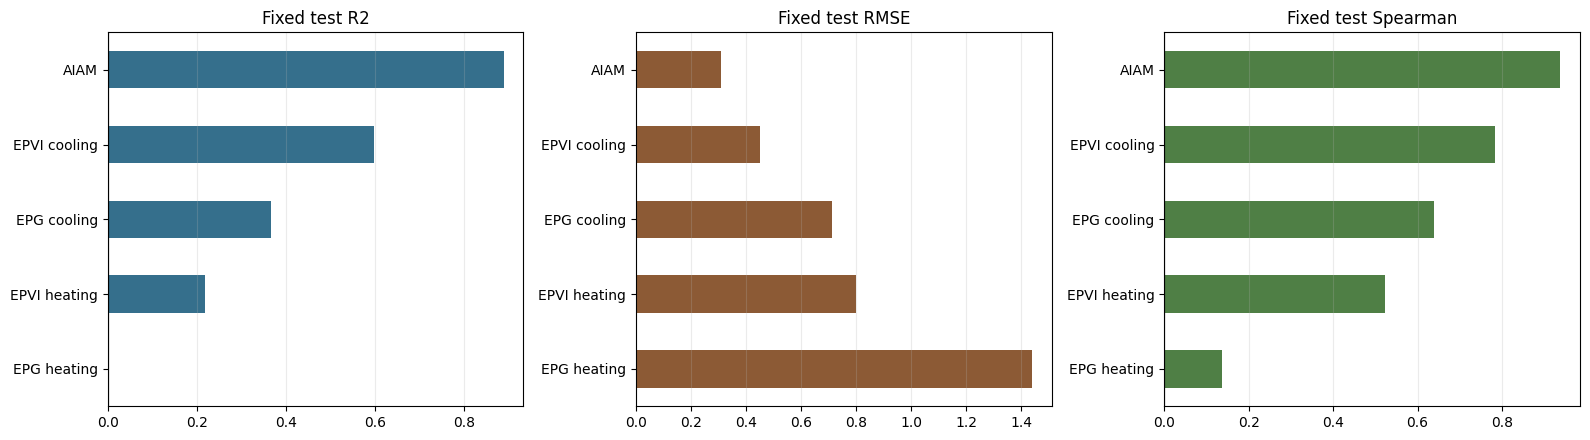

,target,n_train_rows,n_test_rows,n_predictors,fixed_test_r2,fixed_test_mae,fixed_test_rmse,fixed_test_spearman
0,AIAM,2474,618,48,0.888005,0.221591,0.308902,0.937995
1,EPVI cooling,2474,618,48,0.596784,0.343840,0.451367,0.783542
2,EPG cooling,2474,618,48,0.366419,0.539767,0.712319,0.637837
3,EPVI heating,2474,618,48,0.217439,0.557260,0.800399,0.522473
4,EPG heating,2474,618,48,0.001502,0.956332,1.438909,0.137919


In [4]:
metric_cols = ["fixed_test_r2", "fixed_test_mae", "fixed_test_rmse", "fixed_test_spearman"]
plot_df = metrics.sort_values("fixed_test_r2", ascending=True)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_df.plot.barh(x="target", y="fixed_test_r2", ax=axes[0], legend=False, color="#356f8c")
axes[0].set_title("Fixed test R2")
axes[0].axvline(0, color="black", linewidth=0.8)
plot_df.plot.barh(x="target", y="fixed_test_rmse", ax=axes[1], legend=False, color="#8c5a35")
axes[1].set_title("Fixed test RMSE")
plot_df.plot.barh(x="target", y="fixed_test_spearman", ax=axes[2], legend=False, color="#4f7f45")
axes[2].set_title("Fixed test Spearman")
axes[2].axvline(0, color="black", linewidth=0.8)
for ax in axes:
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()
display(metrics[["target", "n_train_rows", "n_test_rows", "n_predictors", *metric_cols]].sort_values("fixed_test_r2", ascending=False))


## Training Spatial CV Diagnostic

These region-held-out metrics describe the tuning distribution on training regions. They are useful for comparison with the fixed test set but are not the final test result.


In [5]:
cv_cols = ["search_spatial_cv_r2_mean", "train_spatial_cv_r2", "train_spatial_cv_mae", "train_spatial_cv_rmse", "train_spatial_cv_spearman", "train_in_sample_r2"]
display(metrics[["target", *cv_cols]].sort_values("train_spatial_cv_r2", ascending=False))


,target,search_spatial_cv_r2_mean,train_spatial_cv_r2,train_spatial_cv_mae,train_spatial_cv_rmse,train_spatial_cv_spearman,train_in_sample_r2
0,AIAM,0.872669,0.876068,0.256628,0.364103,0.939943,0.978637
1,EPVI cooling,0.429342,0.480262,0.438244,0.577971,0.698312,0.929976
3,EPVI heating,0.416615,0.458777,0.568335,0.865301,0.743627,0.928868
4,EPG heating,0.090546,0.222595,1.039283,1.602049,0.505954,0.582514
2,EPG cooling,0.037825,0.197139,0.744587,0.998088,0.407560,0.605737


## Fixed Test Predictions and Residuals


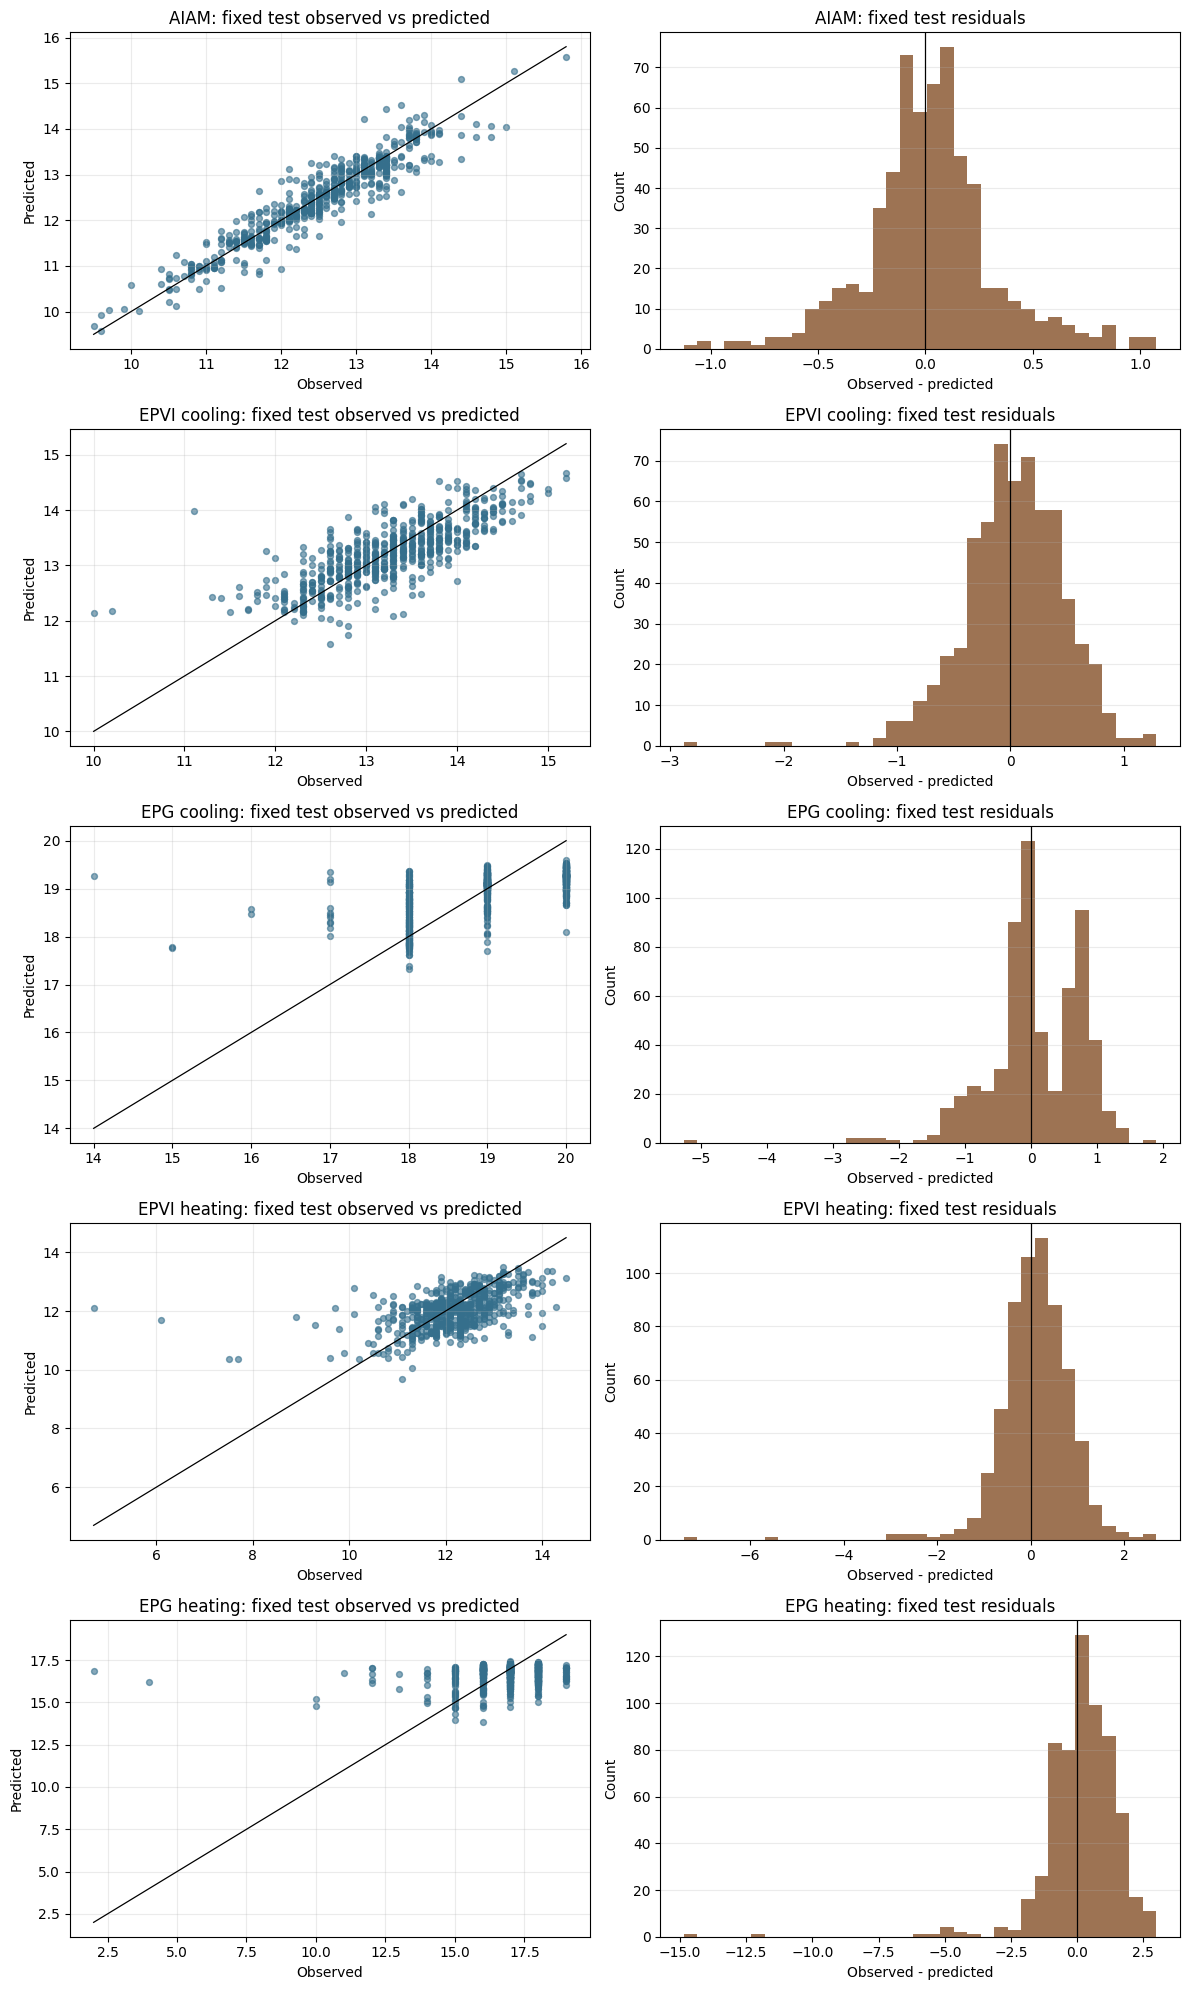

In [6]:
test_predictions = predictions[predictions["prediction_role"] == "fixed_test"].copy()
n_targets = len(target_order)
fig, axes = plt.subplots(n_targets, 2, figsize=(12, 4 * n_targets))
if n_targets == 1:
    axes = np.array([axes])
for row, target in enumerate(target_order):
    df_t = test_predictions[test_predictions["target"] == target].copy()
    ax = axes[row, 0]
    ax.scatter(df_t["observed"], df_t["predicted"], s=18, alpha=0.6, color="#356f8c")
    lo = min(df_t["observed"].min(), df_t["predicted"].min())
    hi = max(df_t["observed"].max(), df_t["predicted"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.9)
    ax.set_title(f"{target}: fixed test observed vs predicted")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
    ax = axes[row, 1]
    ax.hist(df_t["residual"].dropna(), bins=35, color="#8c5a35", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_title(f"{target}: fixed test residuals")
    ax.set_xlabel("Observed - predicted")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [7]:
largest_residuals = []
for target in target_order:
    df_t = test_predictions[test_predictions["target"] == target].copy()
    df_t["abs_residual"] = df_t["residual"].abs()
    largest_residuals.append(df_t.sort_values("abs_residual", ascending=False)[["target", "ID_norm", "NUTS3", "name", "observed", "predicted", "residual", "abs_residual"]].head(15))
display(pd.concat(largest_residuals, ignore_index=True))


,target,ID_norm,NUTS3,name,observed,predicted,residual,abs_residual
0,AIAM,030351,PT112,Braga (São Vítor),13.1,14.224856,-1.124856,1.124856
1,AIAM,091201,PT16J,Alvoco da Serra,12.0,10.924688,1.075312,1.075312
2,AIAM,030112,PT112,Goães,13.2,12.130864,1.069136,1.069136
3,AIAM,091109,PT16J,Baraçal,14.4,13.340785,1.059215,1.059215
4,AIAM,090758,PT16J,Guarda,13.4,14.446374,-1.046374,1.046374
5,AIAM,100506,PT16B,União das Freguesias do Bombarral e Vale Covo,12.1,13.125037,-1.025037,1.025037
6,AIAM,090322,PT16J,Casas do Soeiro,14.8,13.825311,0.974689,0.974689
7,AIAM,091313,PT16J,Palhais,13.6,12.626082,0.973918,0.973918
8,AIAM,141001,PT16I,São João Baptista,15.0,14.045602,0.954398,0.954398
9,AIAM,110814,PT16B,União das Freguesias de São Bartolomeu dos Gal...,11.7,12.631842,-0.931842,0.931842


## Feature Importances

Impurity importances come from the final model fitted on training regions. Optional permutation importances, when written, are evaluated by the training notebook on the fixed test set.


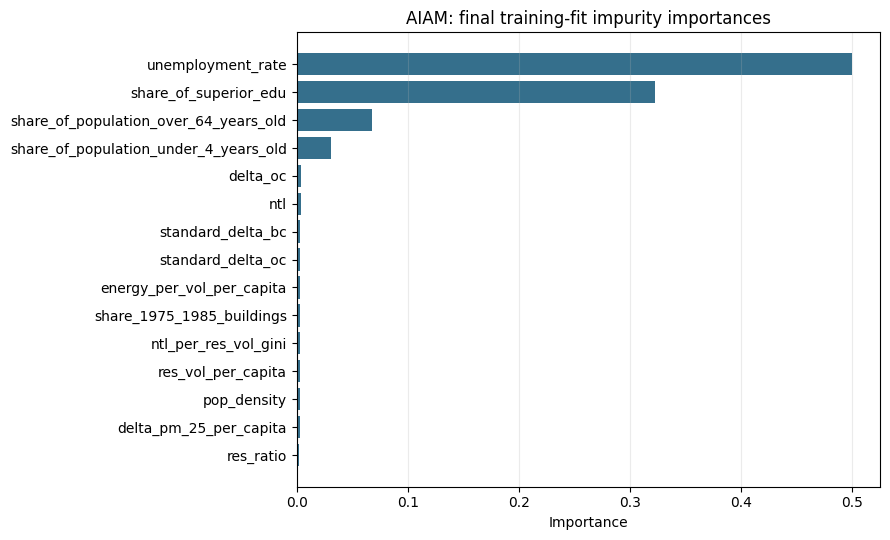

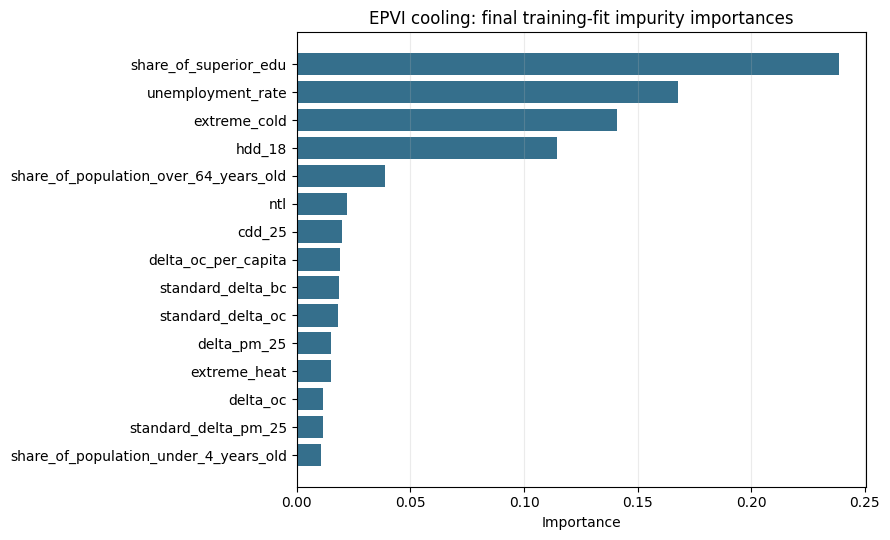

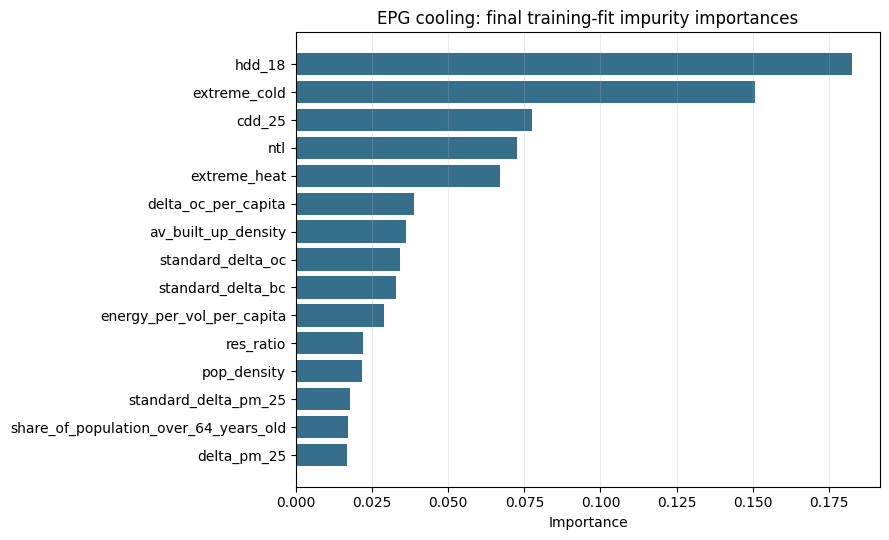

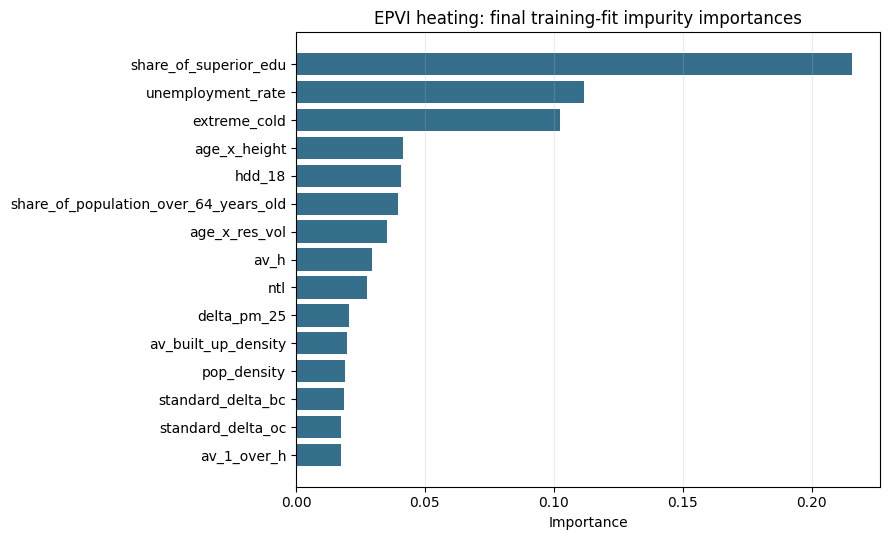

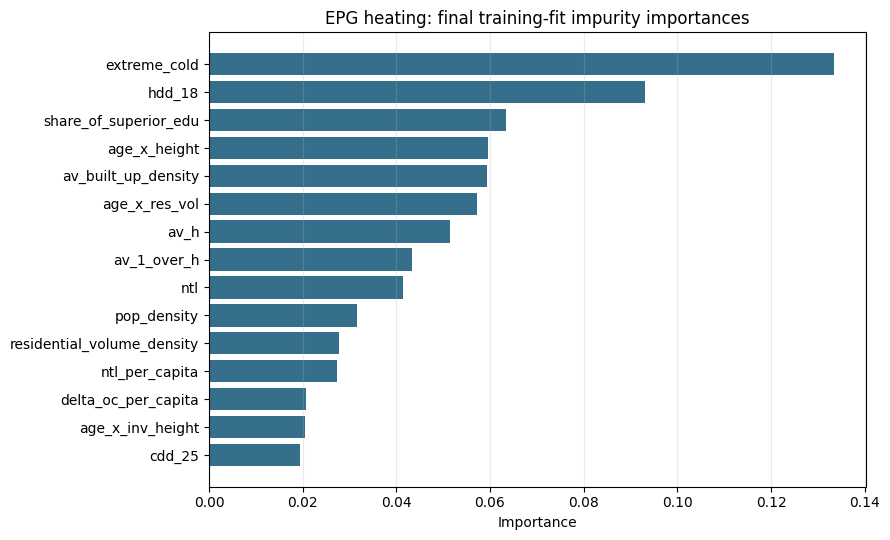

No permutation-importance output found. Enable RUN_PERMUTATION_IMPORTANCE in model_training.ipynb if needed.


In [8]:
TOP_N = 15
for target in target_order:
    df_t = importances[importances["target"] == target].sort_values("impurity_importance", ascending=True).tail(TOP_N)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(df_t["feature"], df_t["impurity_importance"], color="#356f8c")
    ax.set_title(f"{target}: final training-fit impurity importances")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()
if permutation_importances.empty:
    print("No permutation-importance output found. Enable RUN_PERMUTATION_IMPORTANCE in model_training.ipynb if needed.")
else:
    display(permutation_importances.groupby("target").head(15))


## Tuned Hyperparameters


In [9]:
params_df = pd.DataFrame(best_params).T
params_df.index.name = "target"
display(params_df)


,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
target,,,,,
EPG heating,500,5,10,sqrt,6
EPG cooling,500,5,10,sqrt,6
AIAM,500.0,5.0,2.0,1.0,32.0
EPVI heating,1000.0,5.0,2.0,0.35,18.0
EPVI cooling,1000.0,10.0,2.0,0.5,32.0
